Geladene Photontreffer: 78488
Anzahl Ereignisse: 41

Photonstatistik:
        photons  events  arrival_mean_ns  arrival_median_ns  arrival_std_ns  tof_mean_ns  tof_median_ns  tof_std_ns  path_mean_mm
hit                                                                                                                              
bottom    39209      41          51.3474            45.5616         22.3765       1.7911         1.2948      1.6222        0.1846
top       39279      41          51.5416            45.7305         22.7880       1.7896         1.2902      1.6269        0.1852

Gültige Events mit mindestens 1 Photon(en) auf beiden Seiten: 41
<Bottom - Top> = -1.7946 ns
σ(Bottom - Top) = 8.5762 ns
σ einer Seite ≈ 6.0643 ns
Ereignistabelle: event_timing_summary.csv


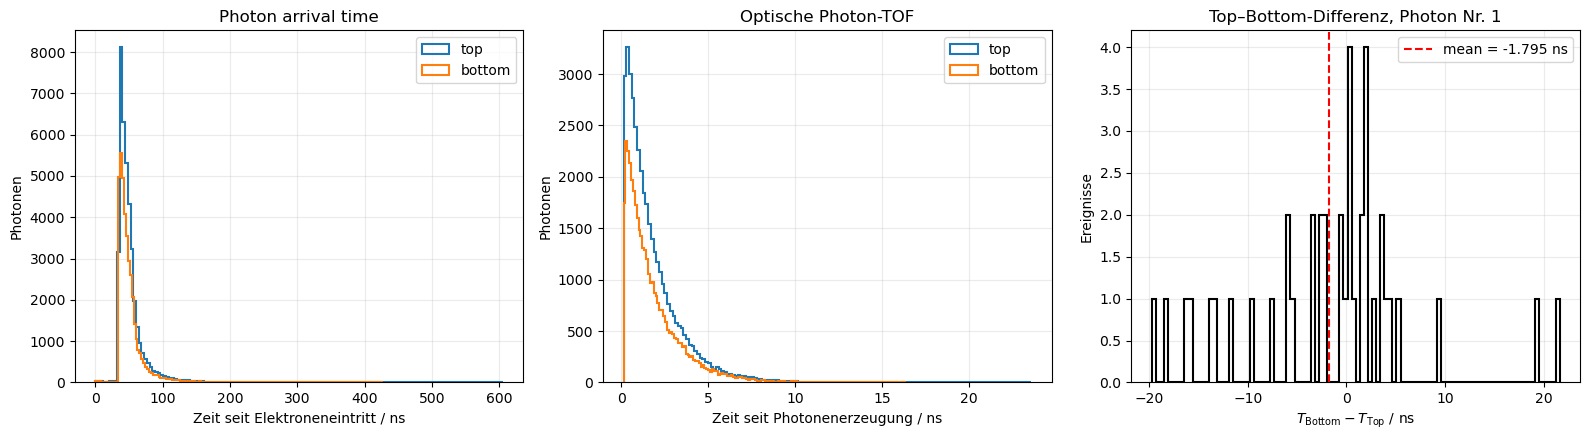

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Einstellungen
# ------------------------------------------------------------

CSV_FILE = Path("data4.csv")

# 1 = erstes Photon als Detektorzeitpunkt
# 5 = fünftes Photon, meist statistisch etwas robuster
NTH_PHOTON = 1

OUTPUT_EVENT_CSV = Path("event_timing_summary.csv")


# ------------------------------------------------------------
# Daten laden und prüfen
# ------------------------------------------------------------

df = pd.read_csv(CSV_FILE, comment="#", header=None, skiprows=12,
names=['eventID', 'globaltime', 'hit', 'photonEnergy', 'photonFlightTime', 'timesinceelectronhit', 'trackID', 'trackLength'])

required_columns = {
    "eventID",
    "trackID",
    "hit",
    "globaltime",
    "timesinceelectronhit",
    "trackLength",
    "photonEnergy",
    "photonFlightTime",
}

missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise RuntimeError(
        f"Fehlende CSV-Spalten: {sorted(missing_columns)}"
    )

# Ungültige oder eventuell leere Zeilen entfernen
df = df.dropna(
    subset=[
        "eventID",
        "trackID",
        "hit",
        "timesinceelectronhit",
        "photonFlightTime",
    ]
).copy()

df["eventID"] = df["eventID"].astype(int)
df["trackID"] = df["trackID"].astype(int)
df["hit"] = df["hit"].astype(str).str.strip().str.lower()

df = df[df["hit"].isin(["top", "bottom"])].copy()

# Aussagekräftigere Spaltennamen
df = df.rename(
    columns={
        "timesinceelectronhit": "arrival_time_ns",
        "photonFlightTime": "photon_tof_ns",
        "trackLength": "track_length_mm",
        "photonEnergy": "photon_energy_eV",
        "globaltime": "global_time_ns",
    }
)

print(f"Geladene Photontreffer: {len(df)}")
print(f"Anzahl Ereignisse: {df['eventID'].nunique()}")
print()


# ------------------------------------------------------------
# Statistik für einzelne Photonen
# ------------------------------------------------------------

photon_statistics = (
    df.groupby("hit")
    .agg(
        photons=("trackID", "count"),
        events=("eventID", "nunique"),
        arrival_mean_ns=("arrival_time_ns", "mean"),
        arrival_median_ns=("arrival_time_ns", "median"),
        arrival_std_ns=("arrival_time_ns", "std"),
        tof_mean_ns=("photon_tof_ns", "mean"),
        tof_median_ns=("photon_tof_ns", "median"),
        tof_std_ns=("photon_tof_ns", "std"),
        path_mean_mm=("track_length_mm", "mean"),
    )
)

print("Photonstatistik:")
print(photon_statistics.to_string(float_format=lambda x: f"{x:.4f}"))
print()


# ------------------------------------------------------------
# Zeitstempel pro Ereignis bestimmen
# ------------------------------------------------------------

# Nach Ankunftszeit sortieren
ordered = df.sort_values(
    ["eventID", "hit", "arrival_time_ns"]
).copy()

# Laufende Nummer jedes Photons innerhalb Event und Seite
ordered["arrival_rank"] = (
    ordered.groupby(["eventID", "hit"])
    .cumcount()
    .add(1)
)

# Gewünschtes Photon auswählen
selected = ordered[
    ordered["arrival_rank"] == NTH_PHOTON
].copy()

# Ankunftszeiten in eine Ereignistabelle bringen
arrival_table = selected.pivot(
    index="eventID",
    columns="hit",
    values="arrival_time_ns",
).rename(
    columns={
        "top": "arrival_top_ns",
        "bottom": "arrival_bottom_ns",
    }
)

# Optische TOF genau dieser ausgewählten Photonen
tof_table = selected.pivot(
    index="eventID",
    columns="hit",
    values="photon_tof_ns",
).rename(
    columns={
        "top": "photon_tof_top_ns",
        "bottom": "photon_tof_bottom_ns",
    }
)

# Photonenzahlen pro Event und Seite
count_table = (
    df.groupby(["eventID", "hit"])
    .size()
    .unstack(fill_value=0)
    .rename(
        columns={
            "top": "n_top",
            "bottom": "n_bottom",
        }
    )
)

events = arrival_table.join(tof_table).join(count_table)

# Nur Ereignisse verwenden, die Top und Bottom besitzen
events = events.dropna(
    subset=[
        "arrival_top_ns",
        "arrival_bottom_ns",
        "photon_tof_top_ns",
        "photon_tof_bottom_ns",
    ]
).copy()

# Top–Bottom-Ankunftszeitdifferenz
events["delta_arrival_ns"] = (
    events["arrival_bottom_ns"]
    - events["arrival_top_ns"]
)

# Kombinierter Ereigniszeitpunkt
events["mean_arrival_ns"] = (
    events["arrival_bottom_ns"]
    + events["arrival_top_ns"]
) / 2.0

# Unterschied der optischen Flugzeiten der ausgewählten Photonen
events["delta_photon_tof_ns"] = (
    events["photon_tof_bottom_ns"]
    - events["photon_tof_top_ns"]
)

events.to_csv(OUTPUT_EVENT_CSV)

print(
    f"Gültige Events mit mindestens {NTH_PHOTON} "
    f"Photon(en) auf beiden Seiten: {len(events)}"
)

if not events.empty:
    mean_delta = events["delta_arrival_ns"].mean()
    sigma_delta = events["delta_arrival_ns"].std(ddof=1)

    # Näherung für zwei gleich gute, unabhängige Seiten
    sigma_single_side = sigma_delta / np.sqrt(2.0)

    print(f"<Bottom - Top> = {mean_delta:.4f} ns")
    print(f"σ(Bottom - Top) = {sigma_delta:.4f} ns")
    print(f"σ einer Seite ≈ {sigma_single_side:.4f} ns")
    print(f"Ereignistabelle: {OUTPUT_EVENT_CSV}")


# ------------------------------------------------------------
# Diagramme
# ------------------------------------------------------------

colors = {
    "top": "tab:blue",
    "bottom": "tab:orange",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Photon-Ankunftszeiten
for side in ["top", "bottom"]:
    values = df.loc[
        df["hit"] == side,
        "arrival_time_ns",
    ]

    axes[0].hist(
        values,
        bins=150,
        histtype="step",
        linewidth=1.5,
        color=colors[side],
        label=side,
    )

axes[0].set_title("Photon arrival time")
axes[0].set_xlabel("Zeit seit Elektroneneintritt / ns")
axes[0].set_ylabel("Photonen")
axes[0].legend()
axes[0].grid(alpha=0.25)

# 2. Reine optische Photon-TOF
for side in ["top", "bottom"]:
    values = df.loc[
        df["hit"] == side,
        "photon_tof_ns",
    ]

    axes[1].hist(
        values,
        bins=150,
        histtype="step",
        linewidth=1.5,
        color=colors[side],
        label=side,
    )

axes[1].set_title("Optische Photon-TOF")
axes[1].set_xlabel("Zeit seit Photonenerzeugung / ns")
axes[1].set_ylabel("Photonen")
axes[1].legend()
axes[1].grid(alpha=0.25)

# 3. Top–Bottom-Zeitdifferenz pro Ereignis
if not events.empty:
    axes[2].hist(
        events["delta_arrival_ns"],
        bins=100,
        histtype="step",
        linewidth=1.5,
        color="black",
    )

    axes[2].axvline(
        events["delta_arrival_ns"].mean(),
        color="red",
        linestyle="--",
        label=(
            f"mean = "
            f"{events['delta_arrival_ns'].mean():.3f} ns"
        ),
    )

axes[2].set_title(
    f"Top–Bottom-Differenz, Photon Nr. {NTH_PHOTON}"
)
axes[2].set_xlabel(
    r"$T_{\mathrm{Bottom}}-T_{\mathrm{Top}}$ / ns"
)
axes[2].set_ylabel("Ereignisse")
axes[2].legend()
axes[2].grid(alpha=0.25)

fig.tight_layout()
fig.savefig("photon_timing_analysis.png", dpi=200)
plt.show()